# Multiuser LoRa Collection Along a UAV Route

This notebook moves from one ground link to the field pilot's first network:

```text
4 fixed ground transmitters -> deterministic packet schedule -> 1 moving UAV receiver
```

The experiment asks three practical questions:

1. where is each packet transmitted along the flight?
2. does propagation provide enough link margin?
3. do packets overlap, and can one be captured?

The primary schedule intentionally avoids managed-node collisions. A simultaneous schedule is included as a controlled failure case. This is raw peer-to-peer LoRa scheduling, not a LoRaWAN MAC implementation.


## 1. Fixed radio profile and packet airtime

All nodes use 923 MHz, SF7, 125 kHz, CR4/5, explicit header, payload CRC, an eight-symbol programmed preamble, a 16-byte payload, and 14 dBm conducted transmit power. The settings follow the repository's proposed first field experiment and must still be checked against the applicable regional rules.


In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.25})

C = 299_792_458.0
FC_HZ = 923e6
BW_HZ = 125e3
SF = 7
CODING_RATE_INDEX = 1
PAYLOAD_BYTES = 16
PREAMBLE_SYMBOLS = 8
TX_POWER_DBM = 14.0

def lora_time_on_air_s(sf, bandwidth_hz, coding_rate_index, payload_bytes):
    symbol_time_s = (1 << sf) / bandwidth_hz
    low_data_rate_optimization = int(symbol_time_s >= 0.016)
    numerator = 8 * payload_bytes - 4 * sf + 28 + 16
    denominator = 4 * (sf - 2 * low_data_rate_optimization)
    payload_symbols = 8 + max(math.ceil(numerator / denominator) * (coding_rate_index + 4), 0)
    return (PREAMBLE_SYMBOLS + 4.25 + payload_symbols) * symbol_time_s

PACKET_AIRTIME_S = lora_time_on_air_s(SF, BW_HZ, CODING_RATE_INDEX, PAYLOAD_BYTES)
assert np.isclose(PACKET_AIRTIME_S, 0.051456)
print(f"Packet airtime: {1e3 * PACKET_AIRTIME_S:.3f} ms")


Packet airtime: 51.456 ms


## 2. Four ground nodes and one continuous flight

The UAV flies east for 1 km at 4 m/s and 30 m altitude. Packet interval is 4 s, producing approximately 16 m along-track spacing per node. The path model is deliberately transparent: log-distance loss, fixed installation loss, a central obstruction term, and reproducible packet-scale fading. Replace it with calibrated RT or measured link predictions later.


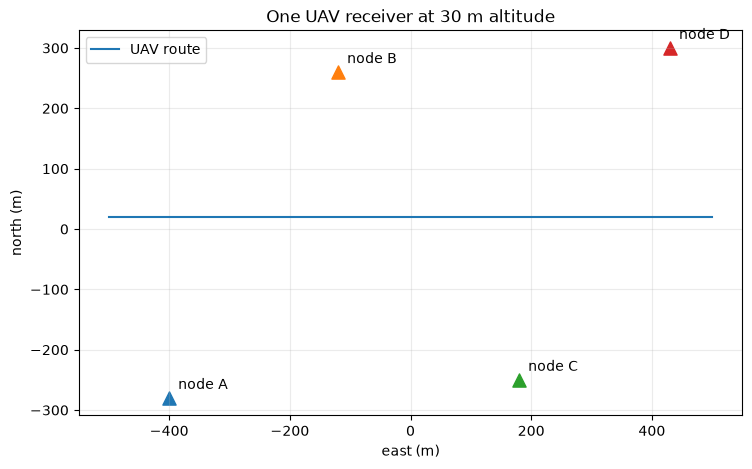

In [2]:
GROUND_NODES = (
    ("A", -400.0, -280.0),
    ("B", -120.0, 260.0),
    ("C", 180.0, -250.0),
    ("D", 430.0, 300.0),
)
FLIGHT_DURATION_S = 250.0
UAV_SPEED_MPS = 4.0
UAV_ALTITUDE_M = 30.0
PACKET_INTERVAL_S = 4.0

def uav_position_at(time_s):
    return np.array([-500.0 + UAV_SPEED_MPS * time_s, 20.0, UAV_ALTITUDE_M])

route_time_s = np.linspace(0, FLIGHT_DURATION_S, 251)
route_position = np.stack([uav_position_at(time_s) for time_s in route_time_s])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(route_position[:, 0], route_position[:, 1], label="UAV route")
for node_name, east_m, north_m in GROUND_NODES:
    ax.scatter(east_m, north_m, marker="^", s=90)
    ax.text(east_m + 15, north_m + 15, f"node {node_name}")
ax.set(title=f"One UAV receiver at {UAV_ALTITUDE_M:g} m altitude", xlabel="east (m)", ylabel="north (m)", aspect="equal")
ax.legend()
plt.show()


## 3. Create one record per transmitted packet

Each record retains node ID, sequence number, transmit time, UAV pose, distance, predicted RSSI/SNR, collision state, and reception outcome. The RSSI field is named **predicted** because a physically lost packet would not provide a measured packet RSSI.

Reception probability is a logistic function of SNR margin. Colliding packets are all lost unless the strongest exceeds the second strongest by a 6 dB capture threshold. This simplified capture rule must be replaced by receiver-specific collision measurements for publication-quality results.


In [3]:
NOISE_FIGURE_DB = 6.0
MOTOR_DESENSE_DB = 3.0
REQUIRED_SNR_DB = -7.5
CAPTURE_THRESHOLD_DB = 6.0
PATH_LOSS_EXPONENT = 3.2
INSTALLATION_LOSS_DB = 6.0
noise_floor_dbm = -174 + 10 * np.log10(BW_HZ) + NOISE_FIGURE_DB + MOTOR_DESENSE_DB
free_space_loss_1m_db = 20 * np.log10(4 * np.pi * FC_HZ / C)

def make_packet_records(slot_offsets_s):
    records = []
    for node_index, ((node_name, node_east_m, node_north_m), slot_offset_s) in enumerate(zip(GROUND_NODES, slot_offsets_s)):
        transmit_times_s = np.arange(0.2 + slot_offset_s, FLIGHT_DURATION_S, PACKET_INTERVAL_S)
        for sequence_number, transmit_time_s in enumerate(transmit_times_s):
            uav_position = uav_position_at(transmit_time_s)
            node_position = np.array([node_east_m, node_north_m, 1.5])
            distance_m = np.linalg.norm(uav_position - node_position)
            central_obstruction_db = 14 * np.exp(-(uav_position[0] / 120)**2)
            path_loss_db = (
                free_space_loss_1m_db
                + 10 * PATH_LOSS_EXPONENT * np.log10(max(distance_m, 1.0))
                + INSTALLATION_LOSS_DB
                + central_obstruction_db
            )
            fading_db = np.random.default_rng(10_000 + node_index * 1000 + sequence_number).normal(0, 2.0)
            predicted_rssi_dbm = TX_POWER_DBM - path_loss_db + fading_db
            predicted_snr_db = predicted_rssi_dbm - noise_floor_dbm
            margin_db = predicted_snr_db - REQUIRED_SNR_DB
            delivery_probability = 1 / (1 + np.exp(-margin_db / 1.8))
            records.append({
                "node": node_name,
                "node_index": node_index,
                "sequence": sequence_number,
                "tx_time_s": float(transmit_time_s),
                "end_time_s": float(transmit_time_s + PACKET_AIRTIME_S),
                "uav_east_m": float(uav_position[0]),
                "uav_north_m": float(uav_position[1]),
                "distance_m": float(distance_m),
                "predicted_rssi_dbm": float(predicted_rssi_dbm),
                "predicted_snr_db": float(predicted_snr_db),
                "delivery_probability": float(delivery_probability),
                "collided": False,
                "captured": False,
                "received": False,
            })
    return records


In [4]:
def apply_collisions_and_reception(records):
    ordered = sorted(records, key=lambda record: record["tx_time_s"])
    overlap_groups = []
    current_group = []
    current_end_s = -np.inf
    for record in ordered:
        if current_group and record["tx_time_s"] >= current_end_s:
            overlap_groups.append(current_group)
            current_group = []
            current_end_s = -np.inf
        current_group.append(record)
        current_end_s = max(current_end_s, record["end_time_s"])
    if current_group:
        overlap_groups.append(current_group)

    for group in overlap_groups:
        winners = group
        if len(group) > 1:
            for record in group:
                record["collided"] = True
            strongest = sorted(group, key=lambda record: record["predicted_rssi_dbm"], reverse=True)
            if strongest[0]["predicted_rssi_dbm"] - strongest[1]["predicted_rssi_dbm"] >= CAPTURE_THRESHOLD_DB:
                winners = [strongest[0]]
                strongest[0]["captured"] = True
            else:
                winners = []
        for record in group:
            draw = np.random.default_rng(50_000 + record["node_index"] * 1000 + record["sequence"]).random()
            record["received"] = record in winners and draw < record["delivery_probability"]
    return records

scheduled_records = apply_collisions_and_reception(make_packet_records((0.0, 0.8, 1.6, 2.4)))
simultaneous_records = apply_collisions_and_reception(make_packet_records((0.0, 0.0, 0.0, 0.0)))

assert not any(record["collided"] for record in scheduled_records)
assert all(record["collided"] for record in simultaneous_records)
print(f"Scheduled packets: {len(scheduled_records)}, received: {sum(record['received'] for record in scheduled_records)}")
print(f"Simultaneous packets: {len(simultaneous_records)}, received: {sum(record['received'] for record in simultaneous_records)}")


Scheduled packets: 251, received: 228
Simultaneous packets: 252, received: 12


## 4. Visualize the schedule before trusting its statistics

The first twelve seconds make the MAC-layer difference obvious. Staggered slots leave far more guard time than this packet requires; simultaneous transmissions overlap on every period.


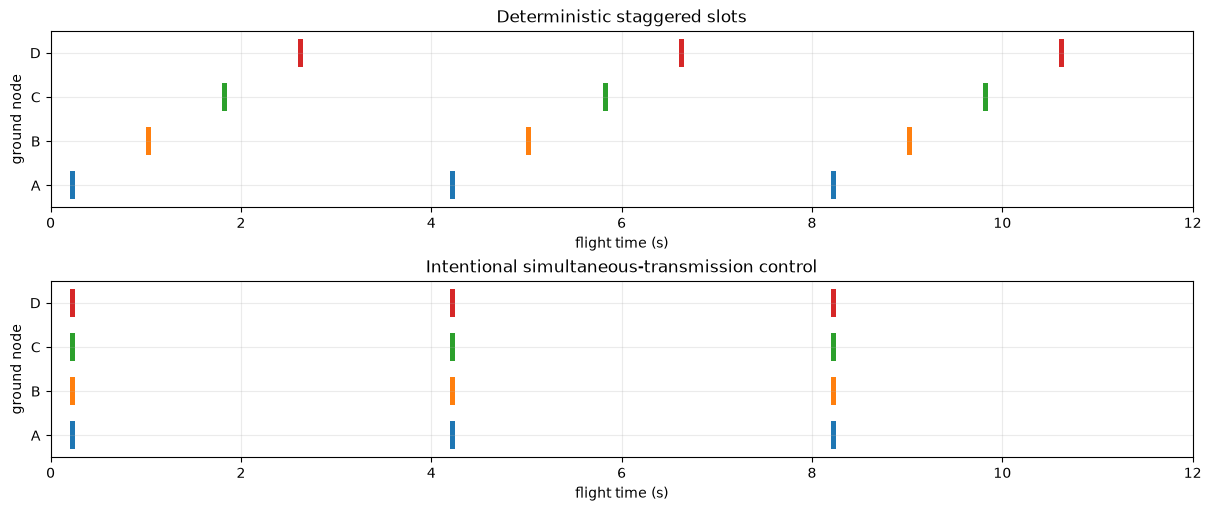

In [5]:
def plot_timeline(ax, records, title):
    for record in records:
        if record["tx_time_s"] > 12:
            continue
        y = record["node_index"]
        color = f"C{record['node_index']}"
        ax.broken_barh([(record["tx_time_s"], PACKET_AIRTIME_S)], (y - 0.32, 0.64), facecolors=color)
    ax.set(title=title, xlabel="flight time (s)", ylabel="ground node", xlim=(0, 12), yticks=range(4), yticklabels=[node[0] for node in GROUND_NODES])

fig, axes = plt.subplots(2, 1, figsize=(12, 5), constrained_layout=True)
plot_timeline(axes[0], scheduled_records, "Deterministic staggered slots")
plot_timeline(axes[1], simultaneous_records, "Intentional simultaneous-transmission control")
plt.show()


## 5. Packet delivery and mission completeness

A mission is called complete here when at least 20 packets are received from every node. This threshold is an experiment requirement, not a LoRa property. Report missing sequence numbers and failed missions rather than discarding them.


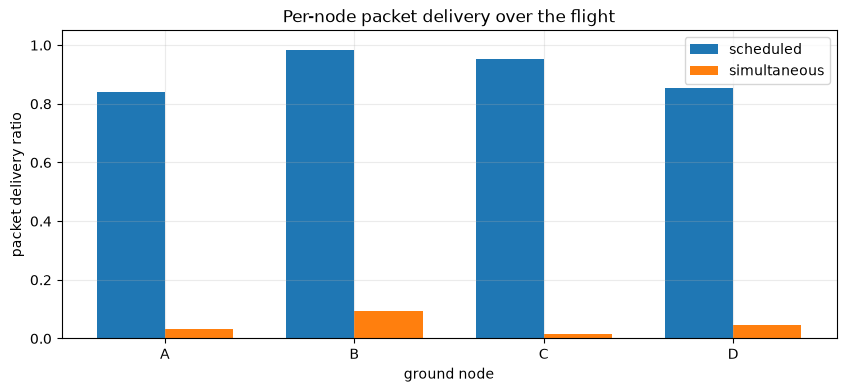

node A: scheduled 53/63, simultaneous  2/63
node B: scheduled 62/63, simultaneous  6/63
node C: scheduled 60/63, simultaneous  1/63
node D: scheduled 53/62, simultaneous  3/63
Scheduled mission complete:    True
Simultaneous mission complete: False


In [6]:
MIN_PACKETS_PER_NODE = 20

def summarize(records):
    summary = {}
    for node_name, _, _ in GROUND_NODES:
        node_records = [record for record in records if record["node"] == node_name]
        received = sum(record["received"] for record in node_records)
        summary[node_name] = {
            "transmitted": len(node_records),
            "received": received,
            "missing": len(node_records) - received,
            "pdr": received / len(node_records),
        }
    return summary

scheduled_summary = summarize(scheduled_records)
simultaneous_summary = summarize(simultaneous_records)
scheduled_complete = all(value["received"] >= MIN_PACKETS_PER_NODE for value in scheduled_summary.values())
simultaneous_complete = all(value["received"] >= MIN_PACKETS_PER_NODE for value in simultaneous_summary.values())

node_names = [node[0] for node in GROUND_NODES]
x = np.arange(len(node_names))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.18, [scheduled_summary[node]["pdr"] for node in node_names], width=0.36, label="scheduled")
ax.bar(x + 0.18, [simultaneous_summary[node]["pdr"] for node in node_names], width=0.36, label="simultaneous")
ax.set(title="Per-node packet delivery over the flight", xlabel="ground node", ylabel="packet delivery ratio", xticks=x, xticklabels=node_names, ylim=(0, 1.05))
ax.legend()
plt.show()

for node_name in node_names:
    scheduled = scheduled_summary[node_name]
    simultaneous = simultaneous_summary[node_name]
    print(f"node {node_name}: scheduled {scheduled['received']:2d}/{scheduled['transmitted']:2d}, simultaneous {simultaneous['received']:2d}/{simultaneous['transmitted']:2d}")
print(f"Scheduled mission complete:    {scheduled_complete}")
print(f"Simultaneous mission complete: {simultaneous_complete}")
assert scheduled_complete and not simultaneous_complete


## 6. Preserve the spatial structure

Overall PDR can hide where failures occur. We bin the scheduled records by UAV east coordinate and show delivery fraction together with packet count. A real analysis should keep raw packets and use grouped confidence intervals by run or spatial block.


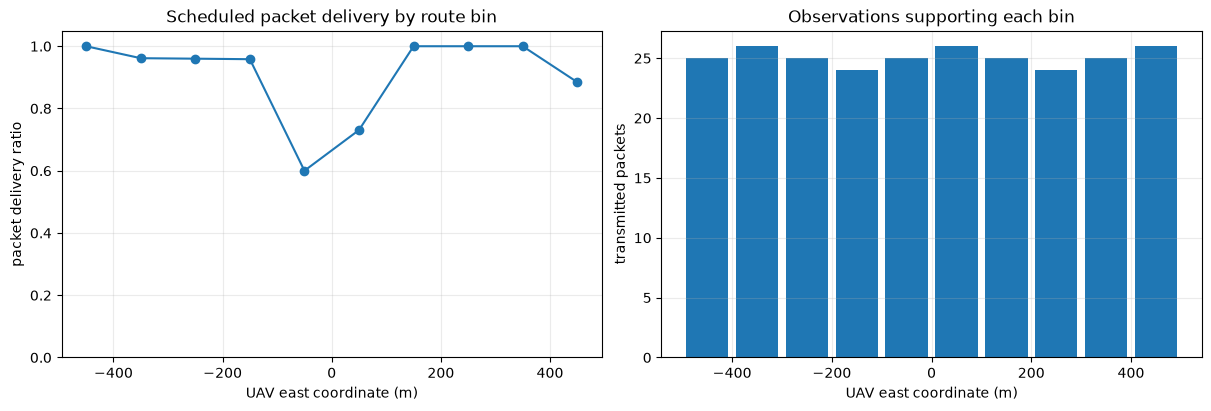

In [7]:
spatial_edges_m = np.arange(-500, 501, 100)
spatial_centres_m = (spatial_edges_m[:-1] + spatial_edges_m[1:]) / 2
spatial_pdr = []
spatial_count = []
for left, right in zip(spatial_edges_m[:-1], spatial_edges_m[1:]):
    records = [record for record in scheduled_records if left <= record["uav_east_m"] < right]
    spatial_count.append(len(records))
    spatial_pdr.append(np.mean([record["received"] for record in records]) if records else np.nan)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(spatial_centres_m, spatial_pdr, marker="o")
axes[0].set(title="Scheduled packet delivery by route bin", xlabel="UAV east coordinate (m)", ylabel="packet delivery ratio", ylim=(0, 1.05))
axes[1].bar(spatial_centres_m, spatial_count, width=85)
axes[1].set(title="Observations supporting each bin", xlabel="UAV east coordinate (m)", ylabel="transmitted packets")
plt.show()


### A UAV is a collector with a finite contact window

For an illustrative usable slant range $R$, vertical separation $h$, and a straight pass centered on one node, $T_{contact}=2\sqrt{R^2-h^2}/v$. With packet interval $T_p$, the approximate number of transmit opportunities is $T_{contact}/T_p$, and along-track spacing is $vT_p$. Boundary alignment can change the integer count. This range threshold is an assumption, not coverage predicted by the earlier channel model.

The left plot tracks the collection requirement per node. The right varies speed while holding range and schedule fixed: faster flight means fewer opportunities even if symbol decoding were perfect. Raising SF can help a weak link but lengthens airtime; extending dwell time costs flight energy. LoRa supports small remote sensor reports, while an elevated receiver supplies the geometry advantage. This does not establish longer UAV endurance or suitability for video or flight-critical control.

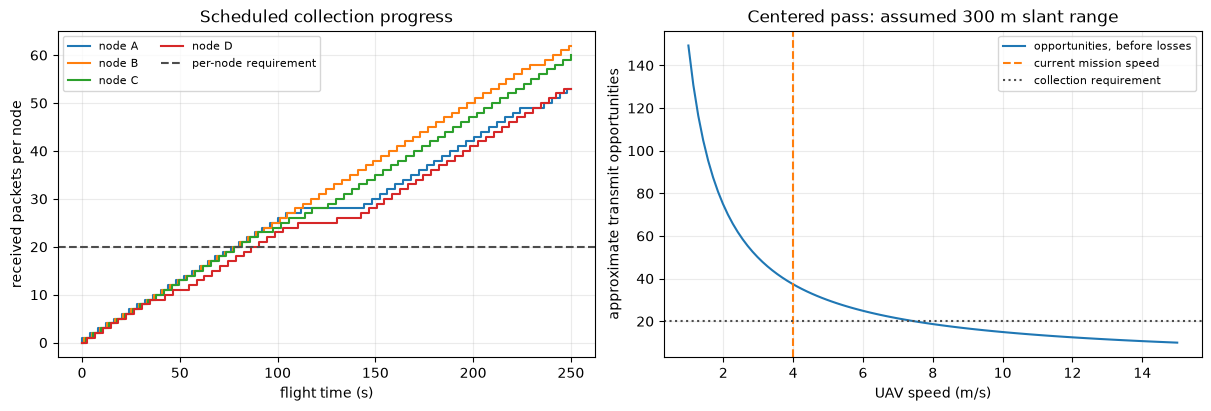

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for node_name, _, _ in GROUND_NODES:
    received = sorted((r for r in scheduled_records if r['node'] == node_name and r['received']), key=lambda r: r['tx_time_s'])
    times = [0] + [r['tx_time_s'] for r in received] + [FLIGHT_DURATION_S]
    counts = [0] + list(range(1, len(received) + 1)) + [len(received)]
    axes[0].step(times, counts, where='post', label=f'node {node_name}')
    assert counts[-1] == scheduled_summary[node_name]['received']
axes[0].axhline(MIN_PACKETS_PER_NODE, color='0.3', ls='--', label='per-node requirement')
axes[0].set(title='Scheduled collection progress', xlabel='flight time (s)', ylabel='received packets per node')
axes[0].legend(fontsize=8, ncol=2)
ILLUSTRATIVE_SLANT_RANGE_M = 300.0
vertical_separation_m = UAV_ALTITUDE_M - 1.5
assert ILLUSTRATIVE_SLANT_RANGE_M > abs(vertical_separation_m)
contact_length_m = 2 * np.sqrt(ILLUSTRATIVE_SLANT_RANGE_M**2 - vertical_separation_m**2)
speeds_mps = np.linspace(1, 15, 100)
opportunities = contact_length_m / speeds_mps / PACKET_INTERVAL_S
axes[1].plot(speeds_mps, opportunities, label='opportunities, before losses')
axes[1].axvline(UAV_SPEED_MPS, color='C1', ls='--', label='current mission speed')
axes[1].axhline(MIN_PACKETS_PER_NODE, color='0.3', ls=':', label='collection requirement')
axes[1].set(title='Centered pass: assumed 300 m slant range', xlabel='UAV speed (m/s)', ylabel='approximate transmit opportunities')
axes[1].legend(fontsize=8)
plt.show()

## 7. Minimum record semantics

Every real packet should retain stable site, run, node, setup, configuration, sequence, and clock identifiers in addition to pose and radio fields. At minimum, distinguish:

- transmitted packet records from received packet records;
- scheduled time, radio timestamp, and aligned UAV-pose timestamp;
- predicted RSS/SNR from measured receiver RSSI/SNR;
- CRC failure, missed sequence number, duplicate, and intentional collision; and
- raw coordinates from derived local ENU coordinates and spatial bins.

Never assign an arbitrary measured RSSI to a lost packet. Non-reception is a valid packet outcome and a censored RSS observation.


## Takeaways

- Deterministic staggered slots separate propagation loss from managed-node collisions.
- A capture model can rescue a dominant packet, but it is receiver-, timing-, SF-, and power-dependent.
- Packet schedules become spatial sampling plans when the receiver is moving. At 4 m/s and a 4 s interval, one node samples roughly every 16 m.
- Per-node PDR, missing sequence numbers, spatial PDR, and complete-collection rate reveal different failure modes.
- The next research step is not automatically reinforcement learning. First replace the transparent path/PER/capture surrogates with calibrated data and compare simple fixed routes and schedules.


## Focused references

- [Data collection from LoRaWAN sensor network by UAV gateway: design, empirical results and dataset](https://oulurepo.oulu.fi/handle/10024/44321): real airborne collection and packet-level measurement methodology.
- A. Waret et al., [LoRa Throughput Analysis with Imperfect Spreading Factor Orthogonality](https://arxiv.org/abs/1803.06534): capture and interference for interpreting collision losses. Our strongest-packet threshold is a teaching surrogate, not a reproduction of that model.

LoRaWAN includes MAC/network behavior beyond the custom schedule here. The useful system result is delivered sensor records per mission and node energy, not merely the lowest SER or largest communication range.